# Lecture 5a — The search is a parameter

**AI-powered Investment and Risk Management**

A backtest is not a number. It is a number *and* the count of alternatives that were tried before that one was shown to you. Report the first without the second and you have not reported a result — you have reported the maximum of a sample, which is a different quantity with different statistical properties.

This notebook makes that concrete. We will find a moving-average rule that looks good, discover where it came from, and then work out what it would have taken for it to be real.

**What you will be able to do afterwards**

- Run a parameter search and read the difference between in-sample and out-of-sample rankings
- Compute the Sharpe ratio you should *expect* from the best of $N$ trials when no strategy has any edge
- Compute and interpret a deflated Sharpe ratio
- Recognise the modelling choices inside a backtest that are doing more work than the signal

**Runtime** — about 40 seconds end to end. No network access needed after the first run.

---

## 0. Setup

Everything shared across the Lecture 5 notebooks lives in `airm5.py`, which should sit in the same folder as this file. On first run the data loaders will download two public files into `./data/` and cache them.

In [36]:
# If you are on Colab, uncomment the next line:
# !pip install -q plotly ipywidgets

import numpy as np
import pandas as pd
import itertools
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

import airm5 as a
from airm5 import C, style

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
rng = np.random.default_rng(42)

# ipywidgets is nicer where you want to drag something, but every widget
# section below also works if you just set the variables by hand.
try:
    import ipywidgets as W
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
print(f"interactive widgets available: {HAS_WIDGETS}")

interactive widgets available: True


## 1. The data, and one honest admission about it

We use the daily closes of S&P 500 constituents, February 2013 to February 2018, and build an equal-weighted, daily-rebalanced index from them.

**WARNING**: There is a problem with that sentence, and we are going to leave it in. The panel contains the companies that were in the index *at the end* of the period, and we keep only those quoted on every date. Any company that failed, merged or was demoted has already been removed for us. This is the survivorship bias from Lecture 2, and it means the index level below is optimistic.

We leave it in because this notebook is about a *different* failure — one that appears even when your data is perfect — and it is worth seeing that the two are independent. A clean dataset does not protect you from what follows.

In [37]:
prices = a.load_daily_panel()
level, rets = a.equal_weight_index(prices)

print(f"Names with full history : {prices.shape[1]}")
print(f"Trading days            : {len(level)}  "
      f"({level.index[0].date()} to {level.index[-1].date()})")
print(f"Index annualised return : {a.ann_return(rets):.2%}")
print(f"Index annualised vol    : {a.ann_vol(rets):.2%}")
print(f"Index Sharpe (buy&hold) : {a.sharpe(rets):.2f}")

Names with full history : 470
Trading days            : 1258  (2013-02-11 to 2018-02-07)
Index annualised return : 13.83%
Index annualised vol    : 12.68%
Index Sharpe (buy&hold) : 1.09


We split 60/40 into a period we are allowed to look at, and a period we are not.

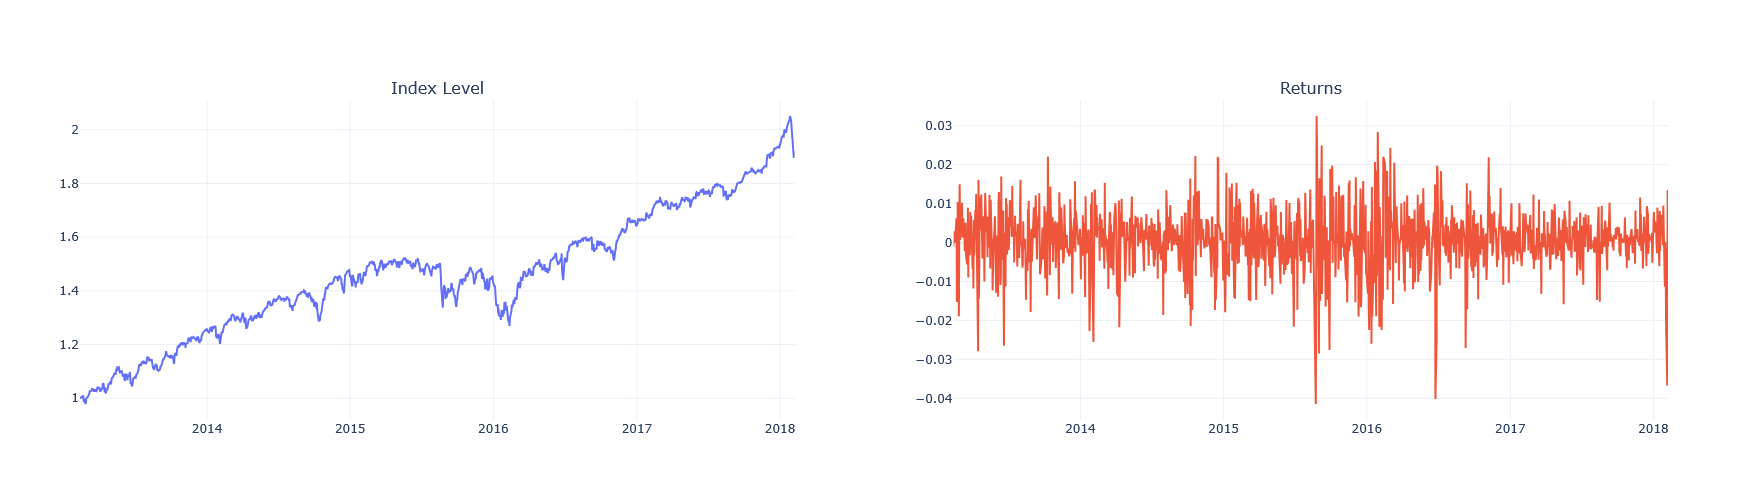

In [38]:
fig = make_subplots(rows=1, cols=2,subplot_titles=("Index Level", "Returns"))

# LHS: prices/index level
fig.add_trace(go.Scatter(x=level.index,y=level.squeeze(),mode="lines",name="Level"),row=1, col=1)
# RHS: returns
fig.add_trace(go.Scatter(x=rets.index,y=rets.squeeze(),mode="lines",name="Returns"),row=1, col=2)

fig.update_layout(height=500,width=1200,template="plotly_white",showlegend=False)
fig.show()

In [39]:
SPLIT = int(len(level) * 0.60)
is_dates, oos_dates = level.index[:SPLIT], level.index[SPLIT:]

print(f"In-sample     : {is_dates[0].date()} to {is_dates[-1].date()}  ({SPLIT} days)")
print(f"Out-of-sample : {oos_dates[0].date()} to {oos_dates[-1].date()}  "
      f"({len(level)-SPLIT} days)")
print(f"\nBuy-and-hold Sharpe, out-of-sample: {a.sharpe(rets.iloc[SPLIT:]):.2f}")

In-sample     : 2013-02-11 to 2016-02-08  (754 days)
Out-of-sample : 2016-02-09 to 2018-02-07  (504 days)

Buy-and-hold Sharpe, out-of-sample: 1.89


## 2. A strategy that looks good

Here is a moving-average crossover rule: hold the index when the 35-day average sits above the 140-day average, and hold nothing otherwise. The signal is computed from data up to and including day $t$, and acted on at $t+1$.

In [40]:
FAST, SLOW = 35, 140
bt = a.ma_crossover(level, rets, FAST, SLOW)

print(f"MA {FAST}/{SLOW}, in-sample:")
print(a.summary(bt.net.iloc[:SPLIT], name=f"MA {FAST}/{SLOW}, in-sample").to_string())
print()
print(f"Buy and hold, in-sample:")
print(a.summary(rets.iloc[:SPLIT], name="Buy and hold, in-sample").to_string())

MA 35/140, in-sample:
CAGR                0.100
Volatility          0.098
Sharpe              1.022
Max drawdown       -0.083
Skew               -0.247
Excess kurtosis     2.438
Observations      754.000

Buy and hold, in-sample:
CAGR                0.088
Volatility          0.138
Sharpe              0.684
Max drawdown       -0.153
Skew               -0.413
Excess kurtosis     1.505
Observations      754.000


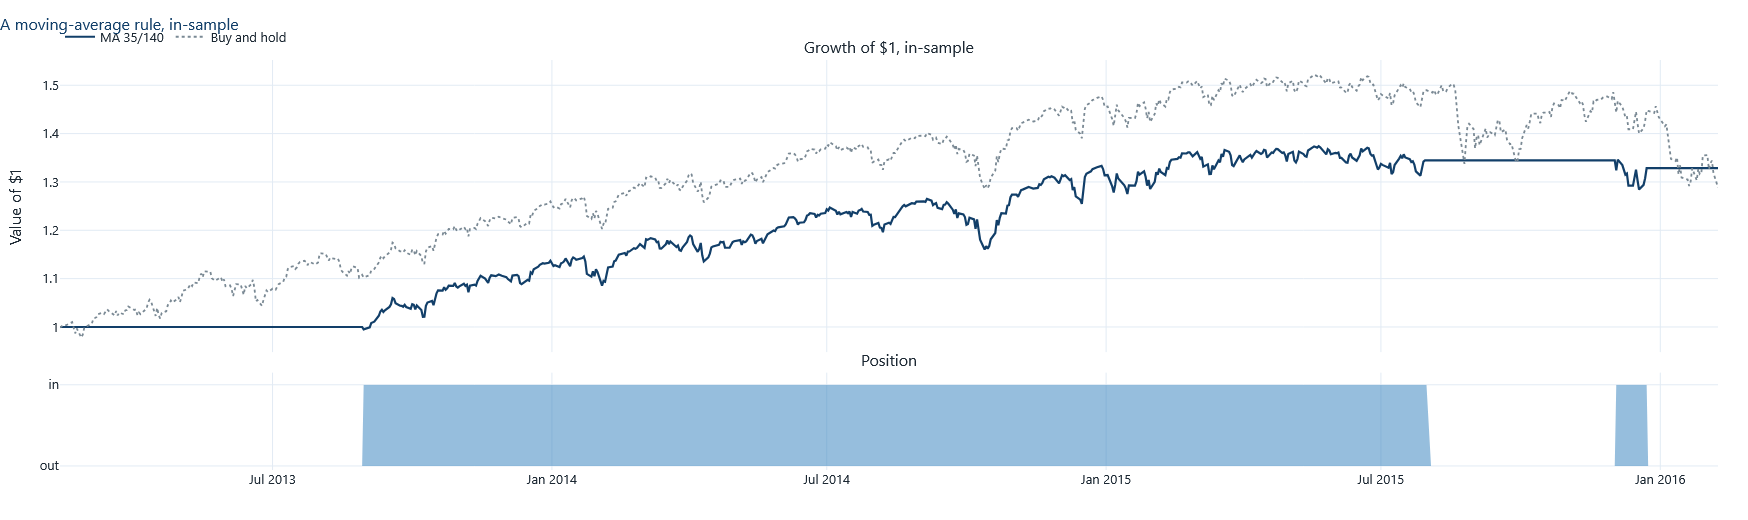

In [41]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.75, 0.25],
                    vertical_spacing=0.05,
                    subplot_titles=("Growth of $1, in-sample", "Position"))

eq_s = (1 + bt.net.iloc[:SPLIT]).cumprod()
eq_b = (1 + rets.iloc[:SPLIT]).cumprod()
fig.add_trace(go.Scatter(x=eq_s.index, y=eq_s, name=f"MA {FAST}/{SLOW}",
                         line=dict(color=C["navy"], width=2.2)), row=1, col=1)
fig.add_trace(go.Scatter(x=eq_b.index, y=eq_b, name="Buy and hold",
                         line=dict(color=C["grey"], width=1.8, dash="dot")), row=1, col=1)
fig.add_trace(go.Scatter(x=is_dates, y=bt.position.iloc[:SPLIT], name="In market",
                         fill="tozeroy", line=dict(color=C["blue"], width=0),
                         showlegend=False), row=2, col=1)
fig.update_yaxes(title_text="Value of $1", row=1, col=1)
fig.update_yaxes(range=[-0.05, 1.15], tickvals=[0, 1], ticktext=["out", "in"], row=2, col=1)
style(fig, height=520, title="A moving-average rule, in-sample")
fig.show()

A Sharpe ratio of 1.02 against buy-and-hold's 0.68, with a drawdown barely half as deep, from a rule anyone can implement in three lines. If someone showed you this, what would you want to know?

The right question is not *how does the rule work*. It is: **where did 35 and 140 come from?**

## 3. Where 35 and 140 came from

They came from a grid. Ten fast windows, ten slow windows, one hundred rules, and 35/140 was the one that won.

In [42]:
FAST_GRID = list(range(5, 55, 5))       # 5, 10, ..., 50
SLOW_GRID = list(range(60, 260, 20))    # 60, 80, ..., 240

records = []
for f, s in itertools.product(FAST_GRID, SLOW_GRID):
    b = a.ma_crossover(level, rets, f, s)
    records.append({
        "fast": f, "slow": s,
        "IS":  a.sharpe(b.net.iloc[:SPLIT]),
        "OOS": a.sharpe(b.net.iloc[SPLIT:]),
    })
grid = pd.DataFrame(records).dropna()

winner = grid.loc[grid.IS.idxmax()]
print(f"Rules evaluated       : {len(grid)}")
print(f"Best in-sample        : {winner.fast:.0f}/{winner.slow:.0f}  "
      f"Sharpe {winner.IS:.2f}")
print(f"Same rule, out-of-sample : Sharpe {winner.OOS:.2f}")

Rules evaluated       : 100
Best in-sample        : 35/140  Sharpe 1.02
Same rule, out-of-sample : Sharpe 1.35


Two heatmaps of the same grid. Use the buttons to switch between the period we searched over and the period we did not.

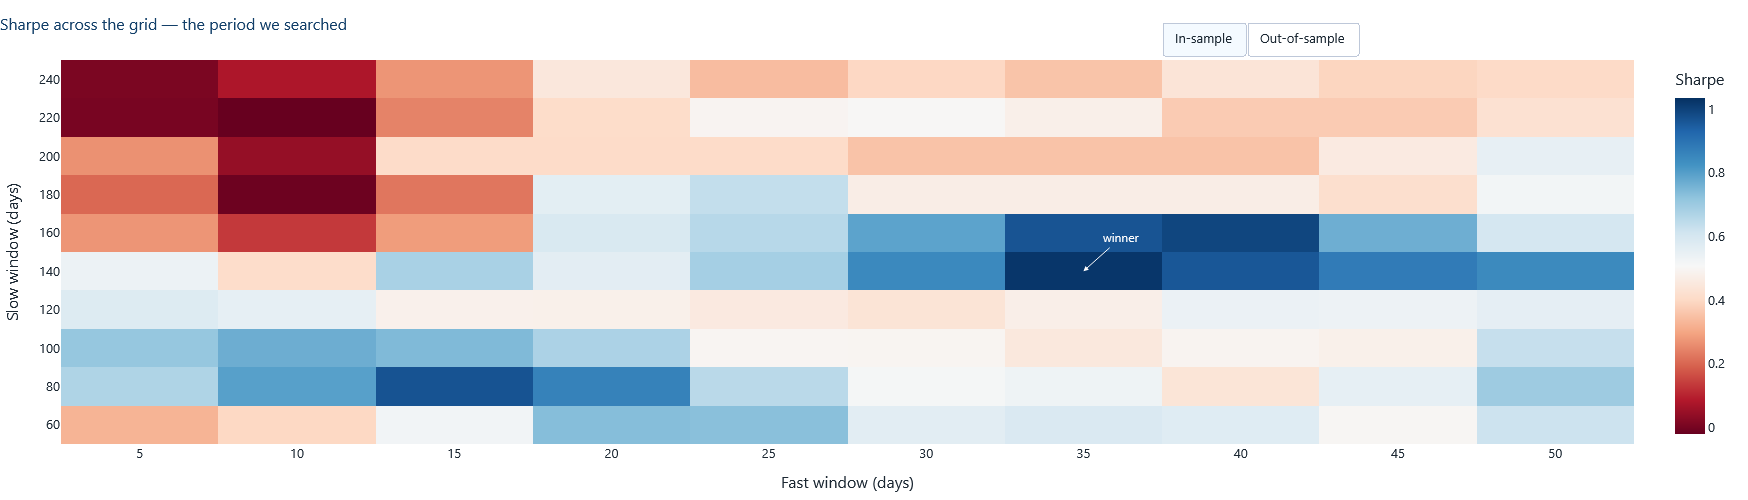

In [43]:
piv_is  = grid.pivot(index="slow", columns="fast", values="IS")
piv_oos = grid.pivot(index="slow", columns="fast", values="OOS")

fig = go.Figure()
for z, name, vis in [(piv_is, "In-sample", True), (piv_oos, "Out-of-sample", False)]:
    fig.add_trace(go.Heatmap(z=z.values, x=z.columns, y=z.index, visible=vis,
                             colorscale="RdBu", zmid=piv_is.values.mean(),
                             colorbar=dict(title="Sharpe"),
                             hovertemplate="fast %{x}<br>slow %{y}<br>"
                                           "Sharpe %{z:.2f}<extra></extra>"))
fig.add_annotation(x=winner.fast, y=winner.slow, text="winner", showarrow=True,
                   arrowhead=2, ax=38, ay=-34, font=dict(color=C["white"], size=12),
                   arrowcolor=C["white"])
fig.update_layout(updatemenus=[dict(
    type="buttons", direction="right", x=.7, y=1.10, xanchor="left",
    buttons=[dict(label="In-sample", method="update",
                  args=[{"visible": [True, False]},
                        {"title": "Sharpe across the grid — the period we searched"}]),
             dict(label="Out-of-sample", method="update",
                  args=[{"visible": [False, True]},
                        {"title": "Sharpe across the grid — the period we did not"}])])])
fig.update_xaxes(title="Fast window (days)", dtick=5)
fig.update_yaxes(title="Slow window (days)", dtick=20)
style(fig, height=500, width=700, legend_top=False,
      title="Sharpe across the grid — the period we searched")
fig.show()

The in-sample surface has structure. There is a ridge, the winner sits on it, and the picture invites you to believe the ridge means something.

Now press *Out-of-sample*. The ridge is gone. Not merely weaker — somewhere else entirely.

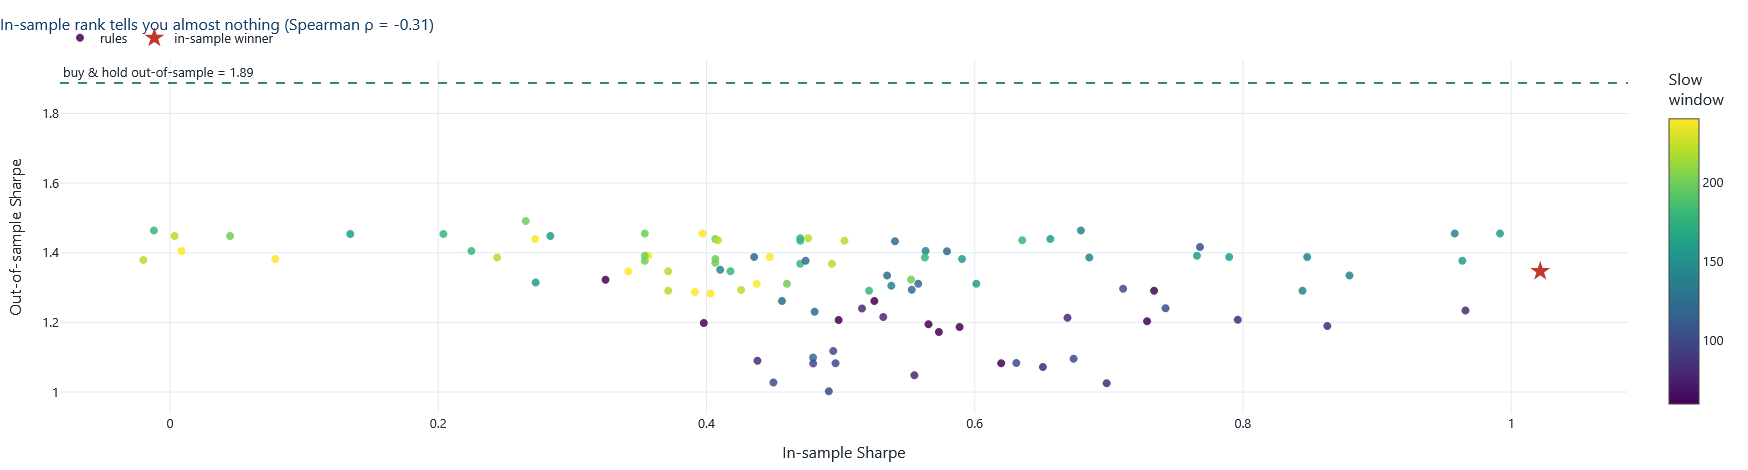

Spearman rank correlation, IS vs OOS : -0.31  (p = 0.00)
Out-of-sample Sharpe across the grid : 1.00 to 1.49
Rules beating buy-and-hold OOS       : 0 of 100


In [44]:
rho, pval = spearmanr(grid.IS, grid.OOS)
bh_oos = a.sharpe(rets.iloc[SPLIT:])

fig = go.Figure()
fig.add_trace(go.Scatter(x=grid.IS, y=grid.OOS, mode="markers",
                         marker=dict(size=8, color=grid.slow, colorscale="Viridis",
                                     showscale=True, opacity=0.85,
                                     colorbar=dict(title="Slow<br>window")),
                         text=[f"{f:.0f}/{s:.0f}" for f, s in zip(grid.fast, grid.slow)],
                         hovertemplate="%{text}<br>IS %{x:.2f} → OOS %{y:.2f}<extra></extra>",
                         name="rules"))
fig.add_trace(go.Scatter(x=[winner.IS], y=[winner.OOS], mode="markers",
                         marker=dict(size=15, color=C["red"], symbol="star"),
                         name="in-sample winner"))
fig.add_hline(y=bh_oos, line=dict(color=C["green"], width=2, dash="dash"),
              annotation_text=f"buy & hold out-of-sample = {bh_oos:.2f}",
              annotation_position="top left")
fig.update_xaxes(title="In-sample Sharpe")
fig.update_yaxes(title="Out-of-sample Sharpe")
style(fig, height=470,
      title=f"In-sample rank tells you almost nothing (Spearman ρ = {rho:+.2f})")
fig.show()

print(f"Spearman rank correlation, IS vs OOS : {rho:+.2f}  (p = {pval:.2f})")
print(f"Out-of-sample Sharpe across the grid : {grid.OOS.min():.2f} to {grid.OOS.max():.2f}")
print(f"Rules beating buy-and-hold OOS       : "
      f"{(grid.OOS > bh_oos).sum()} of {len(grid)}")

Read those three numbers slowly.

The rank correlation is **negative**. Doing well in-sample was, if anything, mildly predictive of doing *worse* afterwards.

And **none of the hundred rules** beat buy-and-hold out-of-sample. Not the winner, not the runner-up, not the worst. The entire exercise — a hundred backtests, a ridge, a story about trend-following — produced nothing that beat holding the index and going away.

Notice also that the winner's out-of-sample Sharpe (1.35) is *higher* than its in-sample Sharpe (1.02). Out-of-sample outperformance is not evidence of anything here: the whole market did better in the second period. Every number needs its benchmark attached.

<details>
<summary><b>The maths: why the maximum is a biased estimate</b></summary>

If you evaluate $N$ strategies with true Sharpe ratios $\theta_i$ and estimate each with error $\varepsilon_i$, you observe $\hat\theta_i = \theta_i + \varepsilon_i$. Selecting the maximum of $\hat\theta$ selects jointly on skill *and* on luck:

$$\mathbb{E}\left[\max_i \hat\theta_i\right] > \max_i \theta_i$$

The gap widens with $N$ and with the dispersion of $\varepsilon$. So the winner of a search is upward-biased *by construction* — before any question of whether the strategies had merit. This is the same phenomenon as the winner's curse in auctions, and it is why the reported Sharpe of a selected strategy is not an unbiased estimate of its future Sharpe.
</details>

## 4. How good would the winner look if nothing worked at all?

The natural objection: perhaps 1.02 is impressive regardless, and the out-of-sample failure was bad luck.

We can answer that. Destroy any genuine structure in the index by resampling its returns in blocks — this preserves the volatility and the fat tails but scrambles any trend that a moving average could detect — then run the *entire hundred-rule grid* on the scrambled series and record the winner. Repeat many times, and you have the distribution of best-of-100 Sharpe ratios under the null hypothesis that nothing works.

In [45]:
def grid_best_sharpe(r, fast_grid, slow_grid, periods=252):
    """Best in-sample Sharpe over the grid, vectorised for the null simulation."""
    lv = np.cumprod(1.0 + r)
    cs = np.concatenate([[0.0], np.cumsum(lv)])
    mas = {w: (cs[w:] - cs[:-w]) / w for w in set(fast_grid) | set(slow_grid)}
    best = -np.inf
    for f, s in itertools.product(fast_grid, slow_grid):
        if f >= s:
            continue
        n = len(lv) - s + 1
        sig = (mas[f][-n:] > mas[s][-n:]).astype(float)
        pos = np.concatenate([[0.0], sig[:-1]])      # act one bar later
        g = pos * r[-n:]
        sd = g.std()
        if sd > 0:
            best = max(best, g.mean() / sd * np.sqrt(periods))
    return best

r_is = rets.iloc[:SPLIT].to_numpy()

def block_bootstrap(x, block=21, rng=rng):
    n = len(x)
    starts = rng.integers(0, n - block, size=n // block + 1)
    return np.concatenate([x[s:s + block] for s in starts])[:n]

N_SIM = 300
null_best = np.array([grid_best_sharpe(block_bootstrap(r_is), FAST_GRID, SLOW_GRID)
                      for _ in range(N_SIM)])

print(f"Best-of-100 Sharpe on scrambled data ({N_SIM} simulations)")
print(f"  median            : {np.median(null_best):.2f}")
print(f"  90th percentile   : {np.percentile(null_best, 90):.2f}")
print(f"  maximum observed  : {null_best.max():.2f}")
print(f"\nOur actual winner  : {winner.IS:.2f}")
print(f"Share of scrambled runs producing a winner at least this good : "
      f"{(null_best >= winner.IS).mean():.1%}")

Best-of-100 Sharpe on scrambled data (300 simulations)
  median            : 1.06
  90th percentile   : 1.81
  maximum observed  : 3.38

Our actual winner  : 1.02
Share of scrambled runs producing a winner at least this good : 53.3%


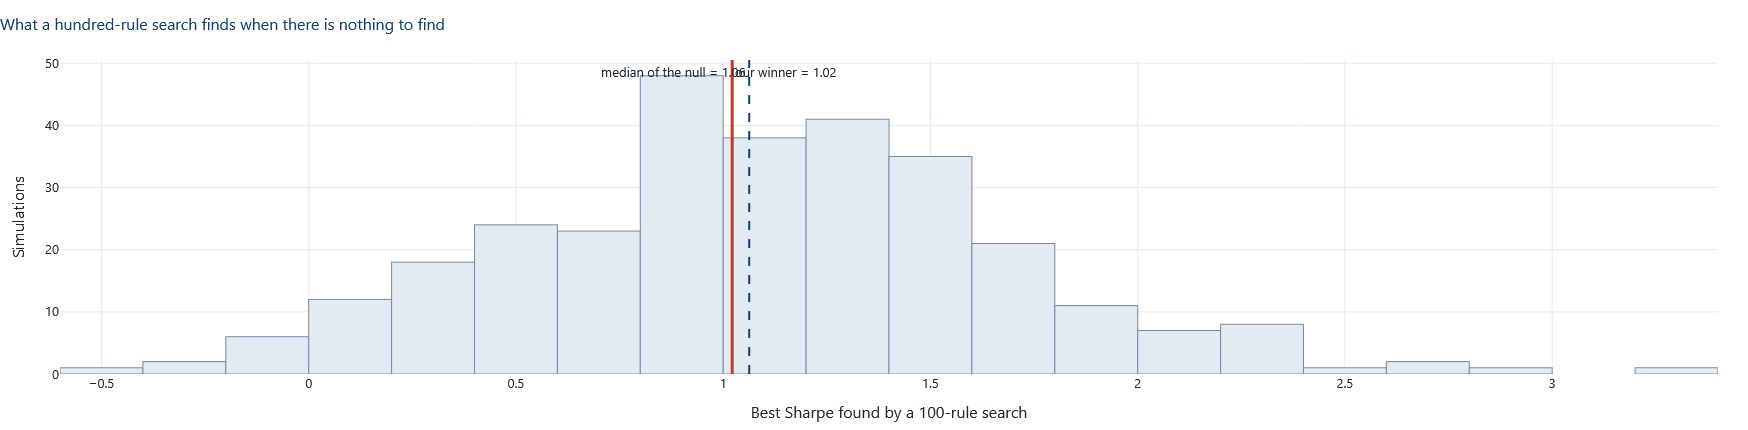

In [46]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=null_best, nbinsx=34, marker_color=C["band"],
                           marker_line=dict(color=C["grey"], width=1),
                           name="best-of-100 on scrambled data"))
fig.add_vline(x=winner.IS, line=dict(color=C["red"], width=3),
              annotation_text=f"our winner = {winner.IS:.2f}",
              annotation_position="top right")
fig.add_vline(x=np.median(null_best), line=dict(color=C["navy"], width=2, dash="dash"),
              annotation_text=f"median of the null = {np.median(null_best):.2f}",
              annotation_position="top left")
fig.update_xaxes(title="Best Sharpe found by a 100-rule search")
fig.update_yaxes(title="Simulations")
style(fig, height=430, legend_top=False,
      title="What a hundred-rule search finds when there is nothing to find")
fig.show()

This is the result to sit with. A grid search over a hundred moving-average rules, run on data with **no exploitable trend structure**, routinely produces a winner with a Sharpe ratio around the value we found and celebrated. More than half of the scrambled runs beat it.

One clarification, because it is the first thing a careful reader should ask. Resampling in blocks scrambles the *order* of returns but preserves their average, so the scrambled series still drifts upward — and a long-only rule that is in the market most of the time inherits that drift. This is deliberate. The null being tested is not "the market went nowhere"; it is "there was no timing information for a moving average to find". That is the claim the rule is actually making, and it is the claim that fails.

The search itself manufactures the number. You do not need a signal.

## 5. The arithmetic: what should a winner have to clear?

The simulation above is expensive and specific. There is a closed form.

Given $N$ trials whose Sharpe ratios have cross-sectional standard deviation $\sigma_{SR}$, the expected maximum under no edge is

$$\mathbb{E}\!\left[\max SR\right] \approx \sigma_{SR}\left[(1-\gamma)\,Z^{-1}\!\left(1 - \tfrac{1}{N}\right) + \gamma\, Z^{-1}\!\left(1 - \tfrac{1}{N e}\right)\right]$$

with $\gamma$ the Euler–Mascheroni constant. This is your hurdle. Beat it and you have something worth a second look; fall short and you have found what a search of that size finds in noise.

In [47]:
sd_trials = grid.IS.std()
print(f"Spread of Sharpe ratios across our {len(grid)} trials: σ = {sd_trials:.3f}\n")

hurdles = pd.DataFrame({
    "Trials run": [2, 10, 100, 1_000, 10_000, 100_000],
})
hurdles["Sharpe needed"] = [a.expected_max_sharpe(n, sd_trials) for n in hurdles["Trials run"]]
print(hurdles.to_string(index=False))
print(f"\nOur winner's in-sample Sharpe : {winner.IS:.2f}")
print(f"Hurdle at N = {len(grid)}              : {a.expected_max_sharpe(len(grid), sd_trials):.3f}")

Spread of Sharpe ratios across our 100 trials: σ = 0.220

 Trials run  Sharpe needed
          2          0.114
         10          0.346
        100          0.557
       1000          0.716
      10000          0.849
     100000          0.966

Our winner's in-sample Sharpe : 1.02
Hurdle at N = 100              : 0.557


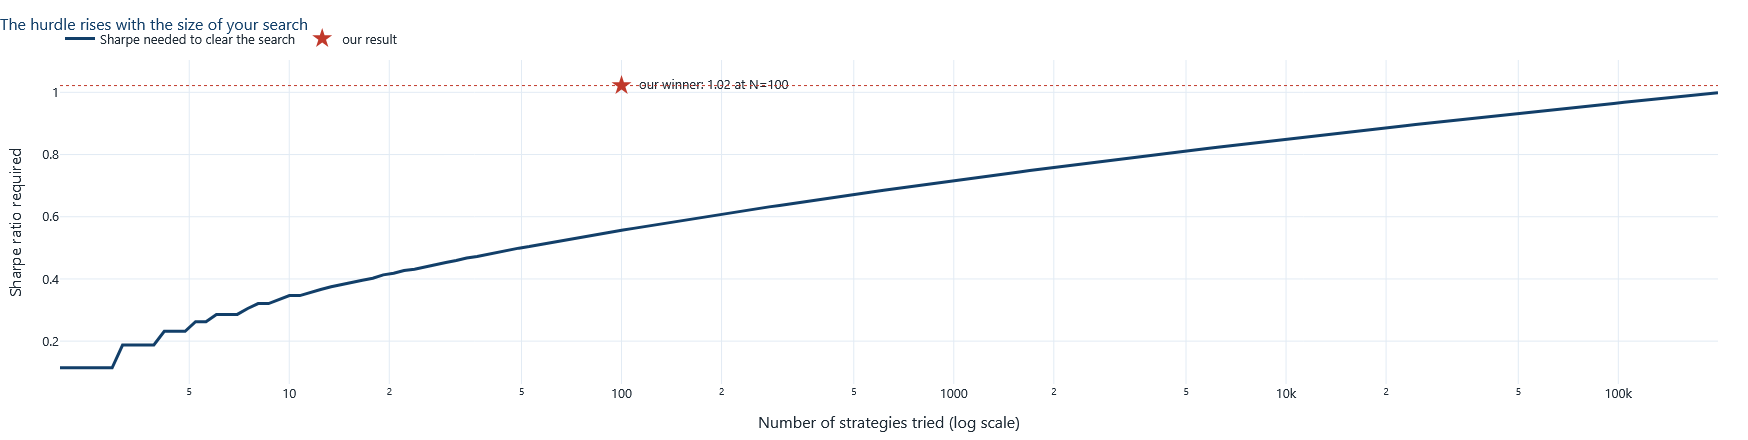

In [48]:
n_axis = np.logspace(0.31, 5.3, 160)
hurdle_curve = [a.expected_max_sharpe(n, sd_trials) for n in n_axis]

fig = go.Figure()
fig.add_trace(go.Scatter(x=n_axis, y=hurdle_curve, mode="lines",
                         line=dict(color=C["navy"], width=3),
                         name="Sharpe needed to clear the search"))
fig.add_trace(go.Scatter(x=[len(grid)], y=[winner.IS], mode="markers+text",
                         marker=dict(size=15, color=C["red"], symbol="star"),
                         text=[f"  our winner: {winner.IS:.2f} at N={len(grid)}"],
                         textposition="middle right", name="our result"))
fig.add_hline(y=winner.IS, line=dict(color=C["red"], width=1, dash="dot"))
fig.update_xaxes(title="Number of strategies tried (log scale)", type="log")
fig.update_yaxes(title="Sharpe ratio required")
style(fig, height=440,
      title="The hurdle rises with the size of your search")
fig.show()

Our winner clears its hurdle, though not comfortably. But the hurdle is only half the correction: it says nothing about how *long* the track record is, or how skewed and fat-tailed the returns are. The **deflated Sharpe ratio** folds all of it together into a single probability — that the true Sharpe exceeds the hurdle, given the sample length, the skew, the kurtosis, and the number of trials.

In [49]:
win_bt = a.ma_crossover(level, rets, int(winner.fast), int(winner.slow))
win_is = win_bt.net.iloc[:SPLIT]

print(f"Winner: MA {winner.fast:.0f}/{winner.slow:.0f}, in-sample\n")
print(f"  Sharpe ratio                       : {a.sharpe(win_is):.2f}")
print(f"  Skew / excess kurtosis             : {win_is.skew():.2f} / {win_is.kurtosis():.2f}")
print(f"  PSR — P(true Sharpe > 0)           : {a.psr(win_is):.3f}")
print(f"  Hurdle from {len(grid)} trials              : "
      f"{a.expected_max_sharpe(len(grid), sd_trials):.2f}")
print(f"  DSR — P(true Sharpe > hurdle)      : "
      f"{a.deflated_sharpe(win_is, len(grid), sd_trials):.3f}")
print(f"\n  Observations needed for 95% confidence vs the hurdle: "
      f"{a.min_track_record_length(win_is, a.expected_max_sharpe(len(grid), sd_trials)):,.0f} days")

Winner: MA 35/140, in-sample

  Sharpe ratio                       : 1.02
  Skew / excess kurtosis             : -0.25 / 2.44
  PSR — P(true Sharpe > 0)           : 0.960
  Hurdle from 100 trials              : 0.56
  DSR — P(true Sharpe > hurdle)      : 0.787

  Observations needed for 95% confidence vs the hurdle: 3,219 days


Against a benchmark of zero the rule looks convincing: a 96% probability the edge is real. Price in the hundred trials and that falls to **79%** — which, for a decision about real money, is not the same statement at all.

And this is the *generous* reading, because we have counted a hundred trials. In practice you also tried a few cost assumptions, two or three split dates, and the version that goes short. Watch what one of those does:

In [50]:
ls_records = []
for f, s in itertools.product(FAST_GRID, SLOW_GRID):
    b = a.ma_crossover(level, rets, f, s, allow_short=True)
    ls_records.append({"fast": f, "slow": s, "IS": a.sharpe(b.net.iloc[:SPLIT])})
ls = pd.DataFrame(ls_records).dropna()
ls_win = ls.loc[ls.IS.idxmax()]
ls_bt = a.ma_crossover(level, rets, int(ls_win.fast), int(ls_win.slow), allow_short=True)
ls_sd = ls.IS.std()

print("Same grid, but the rule is allowed to go short instead of to cash:\n")
print(f"  Best rule                : {ls_win.fast:.0f}/{ls_win.slow:.0f}")
print(f"  Its in-sample Sharpe     : {ls_win.IS:.2f}")
print(f"  Spread across trials     : σ = {ls_sd:.3f}   (was {sd_trials:.3f})")
print(f"  Hurdle at N = {len(ls)}         : {a.expected_max_sharpe(len(ls), ls_sd):.2f}")
print(f"  DSR                      : "
      f"{a.deflated_sharpe(ls_bt.net.iloc[:SPLIT], len(ls), ls_sd):.3f}")

Same grid, but the rule is allowed to go short instead of to cash:

  Best rule                : 35/140
  Its in-sample Sharpe     : 0.76
  Spread across trials     : σ = 0.314   (was 0.220)
  Hurdle at N = 100         : 0.79
  DSR                      : 0.476


Allowing short positions makes the strategies more volatile, which widens the spread of outcomes across the grid, which raises the hurdle — to 0.79, above the best rule's 0.76. **The long/short winner does not clear its own search.**

Note what did the damage. Not the returns: a different *choice*, made in passing, which enlarged the space being searched.

## 6. Your turn — and the notebook is counting

`TrialCounter` logs every strategy you evaluate through it. Change the windows, change the cost, change the split; each configuration you try is one more trial, and the hurdle rises accordingly.

The point is not to find a good rule. It is to watch what happens to the standard of evidence as you look.

In [51]:
tc = a.TrialCounter("my search")

def try_rule(fast, slow, cost_bps=0.0, allow_short=False, verbose=True):
    """Evaluate one rule in-sample and log it as a trial."""
    b = a.ma_crossover(level, rets, fast, slow, cost_bps=cost_bps,
                       allow_short=allow_short)
    r_is = b.net.iloc[:SPLIT]
    sr = a.sharpe(r_is)
    tag = f"MA {fast}/{slow} @ {cost_bps:.0f}bp{' L/S' if allow_short else ''}"
    tc.record(tag, sr, returns=r_is)
    if verbose:
        h = tc.hurdle()
        h_txt = f"{h:.2f}" if np.isfinite(h) else "—"
        print(f"{tag:26s} Sharpe {sr:5.2f}   "
              f"trial #{tc.n:<3d} hurdle now {h_txt}")
    return sr

# Three rules a sensible person might try.
for f, s in [(20, 100), (50, 200), (35, 140)]:
    try_rule(f, s)

MA 20/100 @ 0bp            Sharpe  0.67   trial #1   hurdle now —
MA 50/200 @ 0bp            Sharpe  0.55   trial #2   hurdle now 0.04
MA 35/140 @ 0bp            Sharpe  1.02   trial #3   hurdle now 0.21


In [52]:
if HAS_WIDGETS:
    f_sl = W.IntSlider(value=35, min=5, max=60, step=5, description="Fast:")
    s_sl = W.IntSlider(value=140, min=60, max=240, step=20, description="Slow:")
    c_sl = W.FloatSlider(value=0, min=0, max=20, step=2.5, description="Cost (bp):")
    sh_cb = W.Checkbox(value=False, description="Allow short")
    btn = W.Button(description="Evaluate this rule", button_style="primary")
    out = W.Output()

    def _on_click(_):
        with out:
            if f_sl.value >= s_sl.value:
                print("Fast window must be shorter than the slow one.")
                return
            try_rule(f_sl.value, s_sl.value, c_sl.value, sh_cb.value)

    btn.on_click(_on_click)
    display(W.VBox([W.HBox([f_sl, s_sl]), W.HBox([c_sl, sh_cb]), btn, out]))
else:
    print("No widgets in this environment — call try_rule(...) directly, e.g.")
    print("    try_rule(fast=25, slow=180, cost_bps=5)")

When you have finished searching, ask the notebook what your search was worth.

In [53]:
verdict = tc.verdict()

Trials recorded this session : 9
Best result                  : MA 35/140 @ 0bp (Sharpe 1.02)
Spread across trials         : 0.247
Hurdle at N = 9              : 0.38
Deflated Sharpe ratio        : 0.866
Verdict                      : clears the hurdle


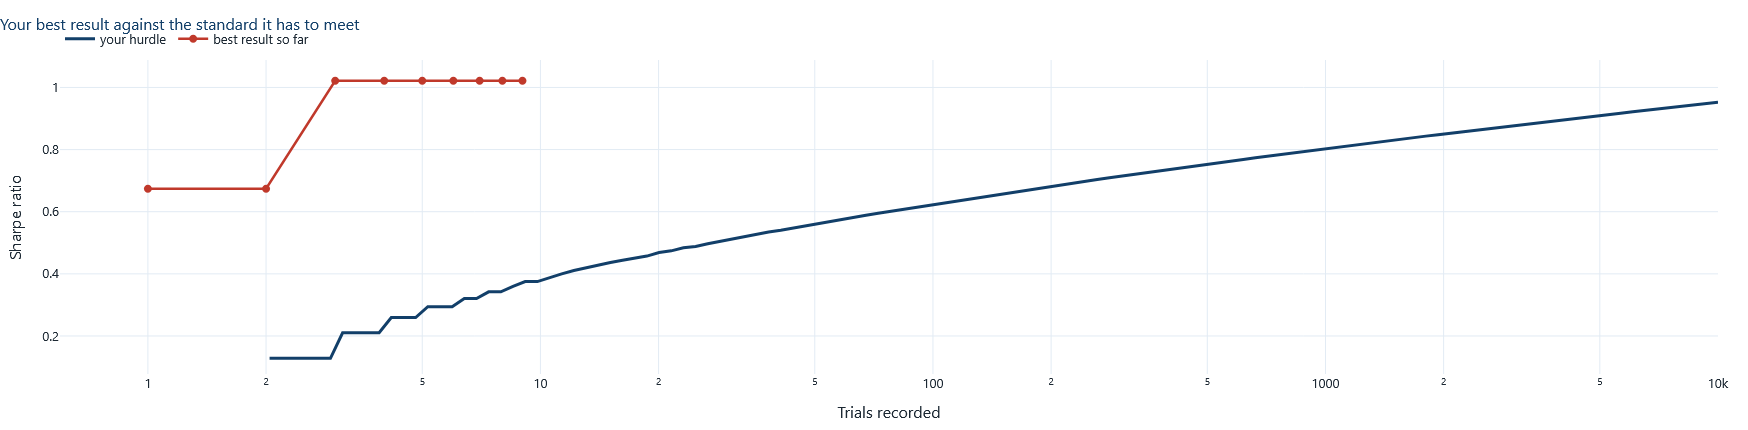

In [54]:
sh = tc.sharpes
n_axis = np.logspace(0.31, 4, 120)

fig = go.Figure()
fig.add_trace(go.Scatter(x=n_axis, y=[a.expected_max_sharpe(n, sh.std(ddof=1))
                                      for n in n_axis],
                         line=dict(color=C["navy"], width=3), name="your hurdle"))
fig.add_trace(go.Scatter(x=np.arange(1, tc.n + 1), y=np.maximum.accumulate(sh),
                         mode="lines+markers", line=dict(color=C["red"], width=2.5),
                         marker=dict(size=8), name="best result so far"))
fig.update_xaxes(title="Trials recorded", type="log")
fig.update_yaxes(title="Sharpe ratio")
style(fig, height=430, title="Your best result against the standard it has to meet")
fig.show()

Run more trials and re-execute the two cells above. The red line can only rise — the maximum of a growing set never falls — but so does the blue one, and the blue one rises for a reason that has nothing to do with markets.

**This is the single most important habit in the notebook.** Not the formula. The habit of knowing your own $N$.

## 7. The complication that makes this honest

If the story ended here it would be too tidy: moving averages are noise, searches are lies, hold the index. That conclusion is not supported, and the same rule family on a different dataset shows why.

Take Robert Shiller's monthly S&P series, which runs from 1871 — 1,775 monthly observations, roughly 148 years — and run the same kind of search: fast windows of 1 to 12 months, slow windows of 6 to 39 months in steps of three, 132 rules, ten basis points of cost per trade.

In [55]:
sh_m = a.load_shiller_monthly()
r_m = sh_m["total_return"].dropna()
lvl_m = (1 + r_m).cumprod()

F_M = list(range(1, 13))
S_M = list(range(6, 40, 3))          # 6, 9, 12, ..., 39 months
SPLIT_M = int(len(r_m) * 0.60)

rec_m = []
for f, s in itertools.product(F_M, S_M):
    if f >= s:
        continue
    b = a.ma_crossover(lvl_m, r_m, f, s, cost_bps=10)
    rec_m.append({"fast": f, "slow": s,
                  "Sharpe": a.sharpe(b.net, periods=12),
                  "IS": a.sharpe(b.net.iloc[:SPLIT_M], periods=12),
                  "OOS": a.sharpe(b.net.iloc[SPLIT_M:], periods=12)})
gm = pd.DataFrame(rec_m).dropna()
wm = gm.loc[gm.Sharpe.idxmax()]
bh_m = a.sharpe(r_m, periods=12)
rho_m = spearmanr(gm.IS, gm.OOS).statistic

print(f"Observations        : {len(r_m):,} months "
      f"({r_m.index[0].date()} to {r_m.index[-1].date()})")
print(f"Rules evaluated     : {len(gm)}")
print(f"Best rule           : {wm.fast:.0f}/{wm.slow:.0f}, Sharpe {wm.Sharpe:.2f}")
print(f"Buy and hold        : Sharpe {bh_m:.2f}")
print(f"IS/OOS Spearman     : {rho_m:+.2f}   (daily panel: {rho:+.2f})")

Observations        : 1,775 months (1871-02-01 to 2018-12-01)
Rules evaluated     : 132
Best rule           : 1/6, Sharpe 0.98
Buy and hold        : Sharpe 0.69
IS/OOS Spearman     : +0.71   (daily panel: -0.31)


In [56]:
wm_bt = a.ma_crossover(lvl_m, r_m, int(wm.fast), int(wm.slow), cost_bps=10)
print(f"MA {wm.fast:.0f}/{wm.slow:.0f}, 1871-2018")
print(a.summary(wm_bt.net, periods=12,
                name=f"MA {wm.fast:.0f}/{wm.slow:.0f}, 1871-2018").to_string())
print()
print("Buy and hold, 1871-2018")
print(a.summary(r_m, periods=12, name="Buy and hold, 1871-2018").to_string())
print(f"\nTime in the market : {(wm_bt.position > 0).mean():.1%}")
print(f"Round trips        : {int((wm_bt.position.diff() > 0).sum())} in {len(r_m):,} months")

MA 1/6, 1871-2018
CAGR                  0.095
Volatility            0.098
Sharpe                0.979
Max drawdown         -0.301
Skew                  0.612
Excess kurtosis       8.735
Observations      1,775.000

Buy and hold, 1871-2018
CAGR                  0.090
Volatility            0.140
Sharpe                0.686
Max drawdown         -0.818
Skew                  0.543
Excess kurtosis      17.912
Observations      1,775.000

Time in the market : 67.7%
Round trips        : 148 in 1,775 months


Same rule family, opposite verdict. Over 148 years the rank correlation between in-sample and out-of-sample performance is **strongly positive**, the winner beats buy-and-hold on Sharpe, and the maximum drawdown is a third of the index's — because the rule was out of the market for much of 1929–32.

Two things separate this from the daily result, and neither is "moving averages work".

1. **Sample size.** 1,775 monthly observations across many regimes, versus 754 daily observations inside a single bull market. The standard error on a Sharpe ratio falls with $\sqrt{T}$, so the daily search was resolving differences it had no power to resolve.
2. **What is being avoided.** The monthly rule's contribution is almost entirely drawdown avoidance in a handful of catastrophes. That is a real property of markets, and it is not the same claim as "this predicts next month's return".

## 8. The choice hiding inside the backtest

One modelling decision has been sitting silently in every number above: **what your money does when the rule is out of the market.**

We assumed it earns nothing. Over 148 years, with the rule in cash a third of the time, that is not a neutral assumption — it is a large bet on interest rates being zero, in a sample that includes double-digit yields.

In [57]:
rows = []
for label, cash in [("Flat cash (our assumption)", None),
                    ("Cash earns the long rate", sh_m["cash_return"])]:
    hits = {}
    for cost in [0, 10, 25, 50, 100]:
        n_beat = sum(
            a.sharpe(a.ma_crossover(lvl_m, r_m, f, s, cost_bps=cost,
                                    cash_return=cash).net, periods=12) > bh_m
            for f, s in itertools.product(F_M, S_M) if f < s)
        hits[f"{cost}bp"] = f"{n_beat}/{len(gm)}"
    b = a.ma_crossover(lvl_m, r_m, int(wm.fast), int(wm.slow),
                       cost_bps=10, cash_return=cash)
    rows.append({"Cash assumption": label,
                 f"Sharpe of {wm.fast:.0f}/{wm.slow:.0f}": a.sharpe(b.net, periods=12),
                 **hits})
print(pd.DataFrame(rows).to_string(index=False))

           Cash assumption  Sharpe of 1/6     0bp    10bp    25bp    50bp   100bp
Flat cash (our assumption)          0.979 116/132 111/132 107/132 102/132  83/132
  Cash earns the long rate          1.143 132/132 132/132 132/132 132/132 131/132


Paying the rule interest on its idle cash lifts its Sharpe from 0.98 to 1.14, and takes the number of rules beating buy-and-hold from 111 of 132 to every single one — at every cost level, including 100 basis points.

Look at the bottom row again. Under the interest-earning assumption, **cost stops mattering**: 132 rules beat buy-and-hold at 0 bp and 131 still do at 100 bp. The cost ladder, which is the thing a careful analyst spends their time on, has been rendered irrelevant by an assumption nobody wrote down.

Neither treatment is wrong. A retail investor holding physical cash earns close to nothing; an institution earns the bill rate. The point is that this single line of the specification moves more verdicts than any parameter in the grid, it was never presented as a decision, and it does not appear in the strategy description at all.

**When you read someone else's backtest, the interesting assumptions are the ones the author did not think were assumptions.**

## 9. Did the effect survive?

A last check on the monthly rule, and the reason to be careful about the word "works". Split 148 years into eras and ask whether the advantage over buy-and-hold is present in each.

      Era  Rule  Buy & hold  Difference
1871–1900 0.719       0.666       0.053
1901–1930 1.168       0.664       0.504
1931–1960 0.889       0.584       0.305
1961–1990 1.052       0.842       0.209
1991–2009 1.187       0.721       0.466
2010–2018 1.100       1.231      -0.132


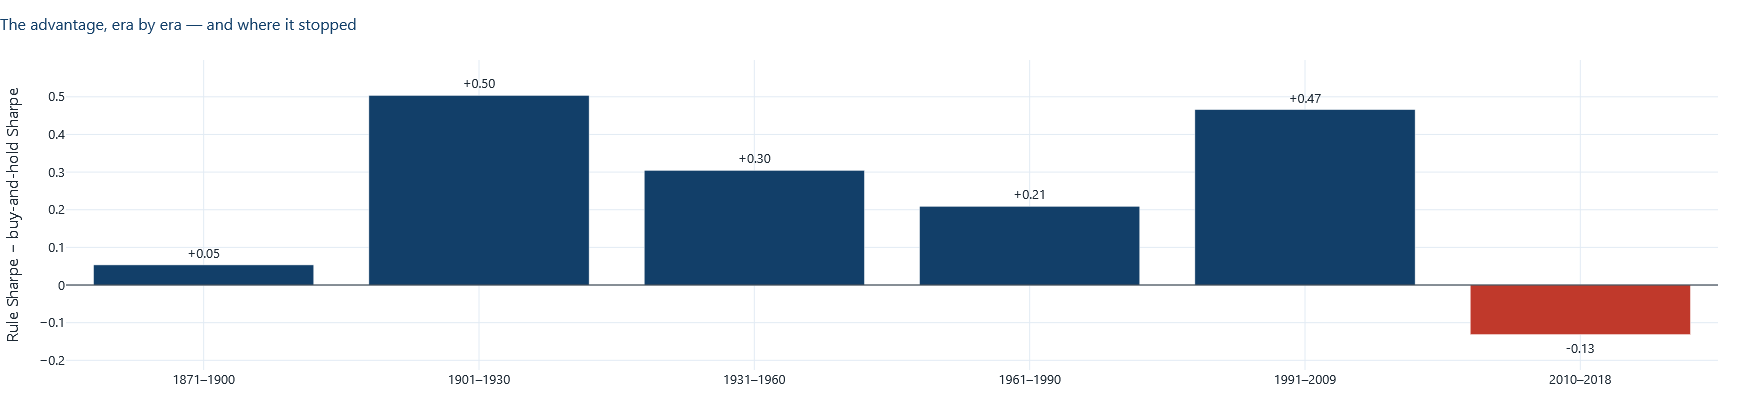

In [58]:
eras = [("1871–1900", "1871", "1900"), ("1901–1930", "1901", "1930"),
        ("1931–1960", "1931", "1960"), ("1961–1990", "1961", "1990"),
        ("1991–2009", "1991", "2009"), ("2010–2018", "2010", "2018")]
rows = []
for name, lo, hi in eras:
    sl = slice(lo, hi)
    s_rule, s_bh = a.sharpe(wm_bt.net[sl], periods=12), a.sharpe(r_m[sl], periods=12)
    rows.append({"Era": name, "Rule": s_rule, "Buy & hold": s_bh,
                 "Difference": s_rule - s_bh})
era = pd.DataFrame(rows)
print(era.to_string(index=False))

fig = go.Figure()
fig.add_trace(go.Bar(x=era.Era, y=era.Difference,
                     marker_color=[C["navy"] if d > 0 else C["red"]
                                   for d in era.Difference],
                     text=[f"{d:+.2f}" for d in era.Difference],
                     textposition="outside"))
fig.add_hline(y=0, line=dict(color=C["ink"], width=1))
fig.update_yaxes(title="Rule Sharpe − buy-and-hold Sharpe")
style(fig, height=420, legend_top=False,
      title="The advantage, era by era — and where it stopped")
fig.show()

Positive in every era for a century and a half, and **negative in the most recent one**.

That is the honest position, and it is uncomfortable in both directions. Anyone claiming the rule is noise has to explain a hundred and forty years. Anyone claiming it works has to explain the last decade — during which, not coincidentally, the result became widely known and cheap to trade.

## 10. What to take away

1. **A result without its $N$ is not a result.** The first question about any backtest is how many were run before you saw this one.
2. **A search manufactures winners.** A hundred moving-average rules on data with no trend structure routinely produces a Sharpe around 1.0. That is what a search of that size finds in noise.
3. **The hurdle rises with the search, and with its variety.** Merely permitting short positions raised the bar above what the best rule achieved.
4. **The deflated Sharpe ratio prices all of it** — trials, sample length, skew, fat tails — into one probability.
5. **Sample size is not a detail.** The same rule family is noise over five years and survives over a hundred and forty.
6. **The dangerous assumptions are the invisible ones.** What idle cash earns moved more verdicts than any parameter in the grid.

Lecture 5b turns to where these numbers come from in the first place: the features you build and the labels you choose.

## Exercises

**Core**

1. Re-run the daily grid with 10 bp of cost per trade. How many of the hundred rules still beat buy-and-hold out-of-sample, and what happens to the hurdle? Explain the direction of the change in the hurdle.
2. Change `SPLIT` from 0.60 to 0.50 and to 0.70. Does the identity of the winner change? If you now report the best of those three, how many trials have you run — 100, or 300?
3. Using `try_rule`, deliberately search until your best result no longer clears its hurdle. Roughly how many trials did that take, and why does it happen even though your best Sharpe keeps rising?
4. The monthly rule spends about a third of its time out of the market. Compute its Sharpe if you assume a 0.5% annual fee on the whole portfolio. Does the conclusion change?

**Stretch**

5. `expected_max_sharpe` assumes the trials are independent. Ours are not: MA 35/140 and MA 35/160 hold nearly the same positions. Estimate the *effective* number of independent trials in the grid — the correlation matrix of the hundred return series is a reasonable starting point — and recompute the hurdle. Is the standard formula conservative or generous here?
6. Rebuild the null simulation in Section 4 using a stationary bootstrap with random block lengths rather than fixed 21-day blocks. Does the distribution of best-of-100 Sharpe shift, and in which direction?
7. Take the monthly winner and compute its deflated Sharpe ratio counting **all** the trials in this notebook — the daily grid, the long/short grid, the monthly grid, both cash assumptions, five cost levels and six eras. Report the total honestly. What does the DSR become?
8. The era analysis chose six era boundaries. Show that a different reasonable choice of boundaries can make the recent underperformance disappear, and say what that implies about era analyses in published papers.